# 3. Exploratory Data Analysis

## Objective

This notebook explores customer characteristics, credit behavior,
repayment history, and their relationships with credit default.

The main objectives are to:

- Understand the distribution of the target variable.
- Compare customer characteristics between default and non-default groups.
- Analyze repayment delay patterns.
- Examine bill and payment behavior.
- Identify variables that may be useful for predicting credit default.

No permanent feature transformation or model training is performed in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/credit_default_clean.csv"
)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_PAYMENT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape

(30000, 24)

### Target Distribution - Findings

In [5]:
default_counts = df["DEFAULT_PAYMENT_NEXT_MONTH"].value_counts().sort_index()

default_percent = (
    df["DEFAULT_PAYMENT_NEXT_MONTH"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(default_counts)
print()
print(default_percent)

DEFAULT_PAYMENT_NEXT_MONTH
0    23364
1     6636
Name: count, dtype: int64

DEFAULT_PAYMENT_NEXT_MONTH
0    77.88
1    22.12
Name: proportion, dtype: float64


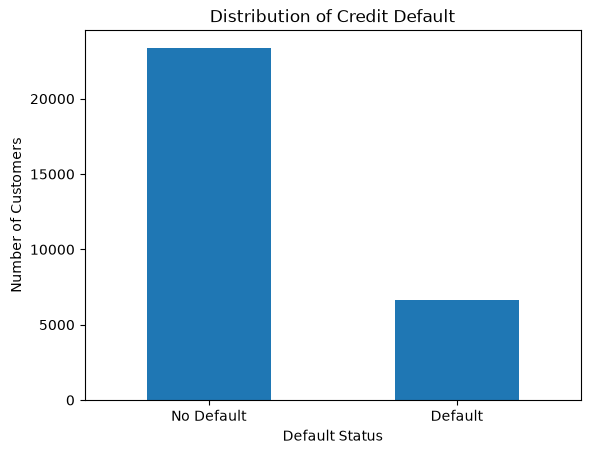

In [6]:
default_counts.plot(kind="bar")

plt.title("Distribution of Credit Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["No Default", "Default"],
    rotation=0
)
plt.show()

The target variable is moderately imbalanced, with non-default customers
representing the majority of observations.

This imbalance is not extreme, but it should be considered during
model evaluation.

Accuracy alone may therefore not be sufficient for evaluating the model.
Metrics such as Precision, Recall, F1-score, ROC-AUC, and PR-AUC
will also be considered.

### Age - Findings

In [7]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

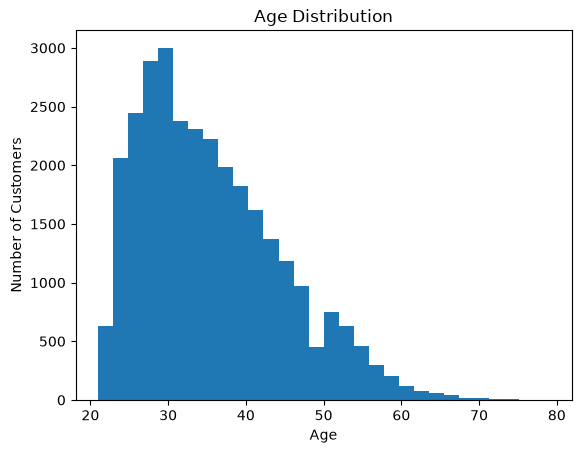

In [8]:
df["AGE"].plot(
    kind="hist",
    bins=30
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
df.groupby("DEFAULT_PAYMENT_NEXT_MONTH")["AGE"].agg([
    "mean",
    "median",
    "min",
    "max"
]).round(2)

,mean,median,min,max
DEFAULT_PAYMENT_NEXT_MONTH,,,,
0,35.42,34.0,21,79
1,35.73,34.0,21,75


In [11]:
eda_df = df.copy()

eda_df["AGE_GROUP"] = pd.cut(
    eda_df["AGE"],
    bins=[20, 30, 40, 50, 60, 100],
    labels=[
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "60+"
    ]
)

In [14]:
age_default_rate = (
    eda_df
    .groupby("AGE_GROUP", observed=False)["DEFAULT_PAYMENT_NEXT_MONTH"]
    .mean()
    .mul(100)
    .round(2)
)

age_default_rate

AGE_GROUP
21-30    22.44
31-40    20.43
41-50    23.30
51-60    25.24
60+      26.84
Name: DEFAULT_PAYMENT_NEXT_MONTH, dtype: float64

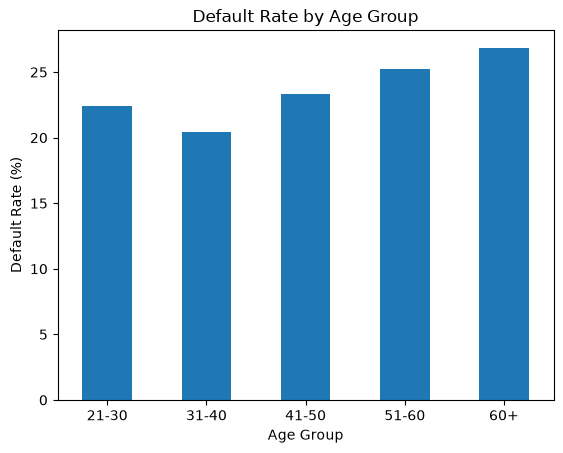

In [15]:
age_default_rate.plot(kind="bar")

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

The age distribution was examined to determine whether default risk
varies across customer age groups.

Age groups were created only for exploratory analysis and do not
replace the original `AGE` feature.

The results will help determine whether age has a meaningful
relationship with credit default.

### Sex - Findings

In [17]:
sex_default = (
    df.groupby("SEX")["DEFAULT_PAYMENT_NEXT_MONTH"]
    .agg(["count", "mean"])
)

sex_default["default_rate"] = (
    sex_default["mean"] * 100
).round(2)

sex_default

,count,mean,default_rate
SEX,,,
1,11888,0.241672,24.17
2,18112,0.207763,20.78


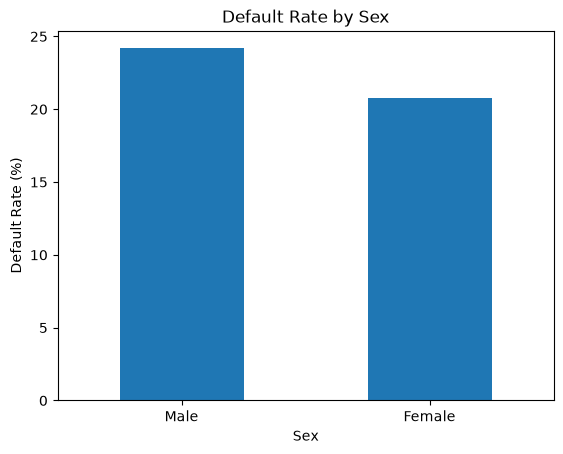

In [18]:
sex_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Default Rate (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["Male", "Female"],
    rotation=0
)
plt.show()

Default rates were compared between male and female customers.

The purpose of this analysis is to determine whether default behavior
differs noticeably between the two groups.

`SEX` will be treated as a categorical variable during preprocessing.

### Education - Findings

In [20]:
education_default = (
    df.groupby("EDUCATION")["DEFAULT_PAYMENT_NEXT_MONTH"]
    .agg(["count", "mean"])
)

education_default["default_rate"] = (
    education_default["mean"] * 100
).round(2)

education_default

,count,mean,default_rate
EDUCATION,,,
1,10585,0.192348,19.23
2,14030,0.237349,23.73
3,4917,0.251576,25.16
4,468,0.070513,7.05


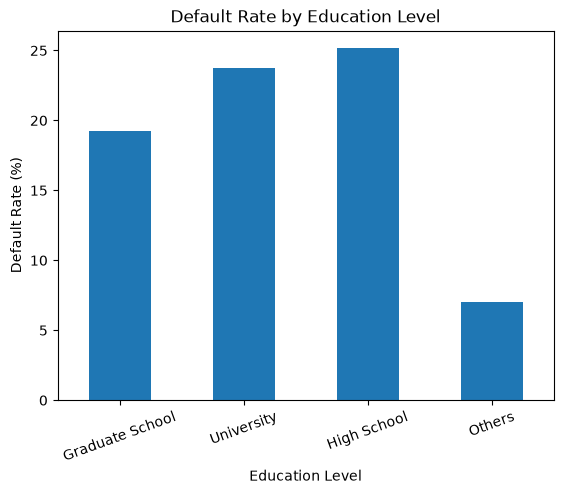

In [21]:
education_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "Graduate School",
        "University",
        "High School",
        "Others"
    ],
    rotation=20
)
plt.show()

Default rates vary across education groups.

The analysis helps determine whether education level contains useful
information for credit risk prediction.

The cleaned `Others` category includes previously undocumented
education values that were consolidated during data cleaning.

### Marriage - Findings

In [23]:
marriage_default = (
    df.groupby("MARRIAGE")["DEFAULT_PAYMENT_NEXT_MONTH"]
    .agg(["count", "mean"])
)

marriage_default["default_rate"] = (
    marriage_default["mean"] * 100
).round(2)

marriage_default

,count,mean,default_rate
MARRIAGE,,,
1,13659,0.234717,23.47
2,15964,0.209283,20.93
3,377,0.236074,23.61


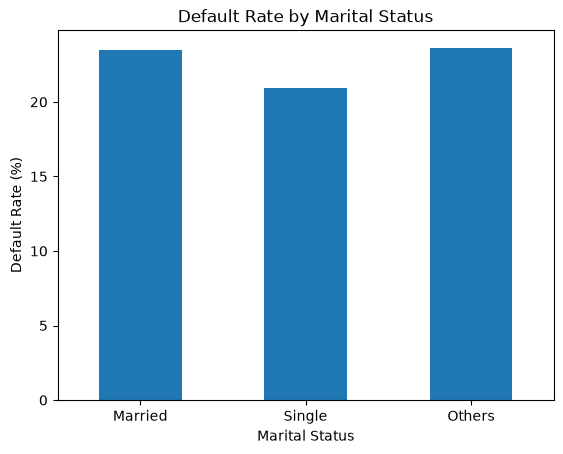

In [24]:
marriage_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")
plt.xticks(
    ticks=[0, 1, 2],
    labels=[
        "Married",
        "Single",
        "Others"
    ],
    rotation=0
)
plt.show()

### Credit Limit - Findings

In [25]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [27]:
df.groupby("DEFAULT_PAYMENT_NEXT_MONTH")["LIMIT_BAL"].agg([
    "mean",
    "median"
]).round(2)

,mean,median
DEFAULT_PAYMENT_NEXT_MONTH,,
0,178099.73,150000.0
1,130109.66,90000.0


In [28]:
eda_df["CREDIT_LIMIT_GROUP"] = pd.qcut(
    eda_df["LIMIT_BAL"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ],
    duplicates="drop"
)

In [30]:
credit_default_rate = (
    eda_df
    .groupby(
        "CREDIT_LIMIT_GROUP",
        observed=False
    )["DEFAULT_PAYMENT_NEXT_MONTH"]
    .mean()
    .mul(100)
)

credit_default_rate

CREDIT_LIMIT_GROUP
Low            31.787389
Medium-Low     24.717625
Medium-High    17.349208
High           13.980473
Name: DEFAULT_PAYMENT_NEXT_MONTH, dtype: float64

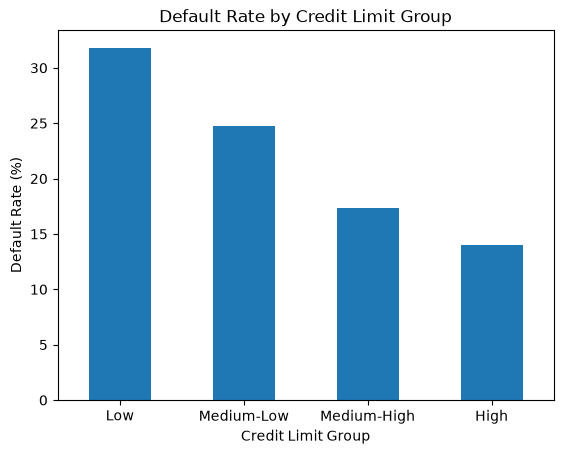

In [31]:
credit_default_rate.plot(kind="bar")

plt.title("Default Rate by Credit Limit Group")
plt.xlabel("Credit Limit Group")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

Credit limit distribution is not uniform across customers.

Customers were temporarily divided into credit-limit groups for
exploratory comparison.

This analysis investigates whether customers with lower or higher
credit limits exhibit different default behavior.

The original continuous `LIMIT_BAL` variable will be preserved for modeling

### Recent Repayment Status - Findings

In [33]:
pay_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

In [35]:
pay0_default = (
    df.groupby("PAY_0")["DEFAULT_PAYMENT_NEXT_MONTH"]
    .agg(["count", "mean"])
)

pay0_default["default_rate"] = (
    pay0_default["mean"] * 100
).round(2)

pay0_default

,count,mean,default_rate
PAY_0,,,
-2,2759,0.132294,13.23
-1,5686,0.167781,16.78
0,14737,0.128113,12.81
1,3688,0.339479,33.95
2,2667,0.691414,69.14
3,322,0.757764,75.78
4,76,0.684211,68.42
5,26,0.500000,50.00
6,11,0.545455,54.55


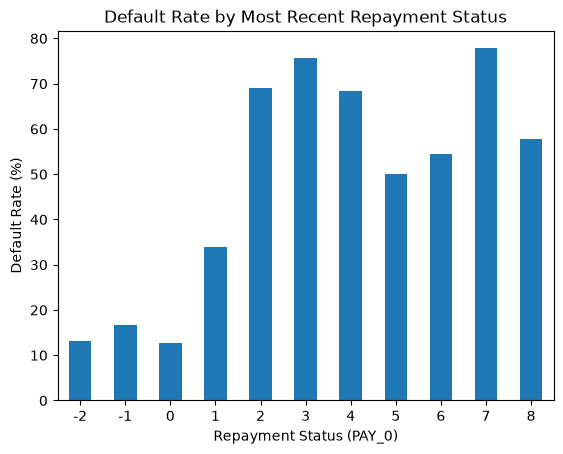

In [36]:
pay0_default["default_rate"].plot(kind="bar")

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("Repayment Status (PAY_0)")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

The most recent repayment status (`PAY_0`) shows how default risk
changes according to recent payment behavior.

Positive repayment-status values represent delayed payments.

This variable is expected to be an important predictor because recent
payment difficulties may indicate increased future default risk.

### Payment Delay Frequency - Findings

In [37]:
eda_df["NUM_DELAYED_MONTHS"] = (
    eda_df[pay_status_cols] > 0
).sum(axis=1)

In [38]:
eda_df["NUM_DELAYED_MONTHS"].value_counts().sort_index()

NUM_DELAYED_MONTHS
0    19931
1     4426
2     1899
3     1154
4      951
5      298
6     1341
Name: count, dtype: int64

In [40]:
delay_default_rate = (
    eda_df
    .groupby("NUM_DELAYED_MONTHS")["DEFAULT_PAYMENT_NEXT_MONTH"]
    .mean()
    .mul(100)
)

delay_default_rate

NUM_DELAYED_MONTHS
0    11.710401
1    29.823769
2    38.757241
3    50.866551
4    57.308097
5    57.382550
6    70.320656
Name: DEFAULT_PAYMENT_NEXT_MONTH, dtype: float64

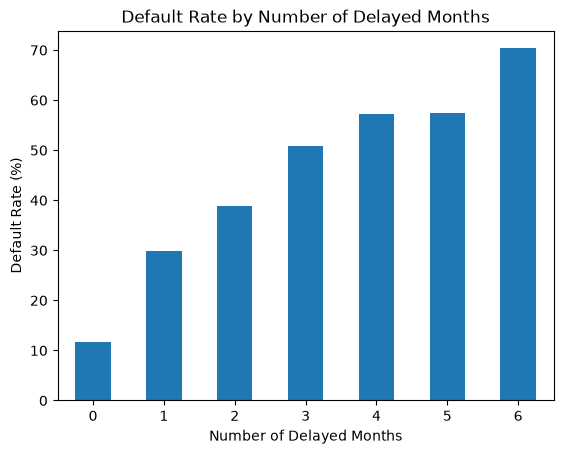

In [41]:
delay_default_rate.plot(kind="bar")

plt.title("Default Rate by Number of Delayed Months")
plt.xlabel("Number of Delayed Months")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

An exploratory variable was created to count the number of months
in which each customer had a positive payment-delay status.

This analysis investigates whether repeated payment delays are
associated with higher default risk.

The feature is created only for EDA at this stage.
A similar feature may later be formally created during feature engineering.

### Bill Amount - Findings

In [43]:
bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

In [45]:
bill_summary = (
    df.groupby("DEFAULT_PAYMENT_NEXT_MONTH")[bill_cols]
    .median()
    .T
)

bill_summary.columns = [
    "No Default",
    "Default"
]

bill_summary

,No Default,Default
BILL_AMT1,23119.5,20185.0
BILL_AMT2,21660.5,20300.5
BILL_AMT3,20202.5,19834.5
BILL_AMT4,19000.0,19119.5
BILL_AMT5,17998.0,18478.5
BILL_AMT6,16679.0,18028.5


Median bill amounts were compared between default and non-default
customers.

Median values are particularly useful because bill amounts may contain
extreme values and skewed distributions.

The objective is to determine whether outstanding bill levels differ
meaningfully between the two customer groups.

### Payment Amount - Findings

In [48]:
payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

In [49]:
payment_summary = (
    df.groupby("DEFAULT_PAYMENT_NEXT_MONTH")[payment_cols]
    .median()
    .T
)

payment_summary.columns = [
    "No Default",
    "Default"
]

payment_summary

,No Default,Default
PAY_AMT1,2459.5,1636.0
PAY_AMT2,2247.5,1533.5
PAY_AMT3,2000.0,1222.0
PAY_AMT4,1734.0,1000.0
PAY_AMT5,1765.0,1000.0
PAY_AMT6,1706.0,1000.0


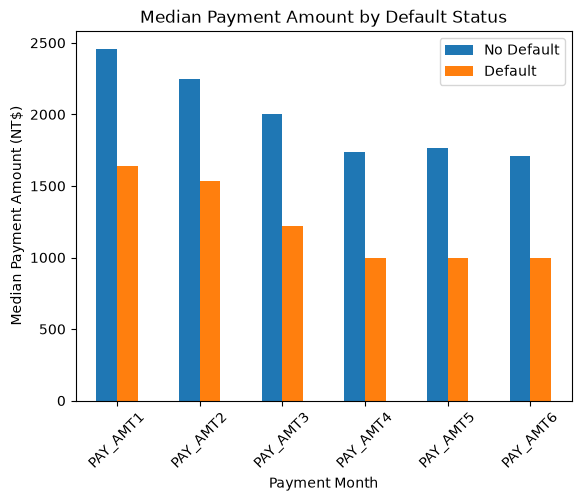

In [50]:
payment_summary.plot(kind="bar")

plt.title("Median Payment Amount by Default Status")
plt.xlabel("Payment Month")
plt.ylabel("Median Payment Amount (NT$)")
plt.xticks(rotation=45)
plt.show()

Historical payment amounts were compared between customers who defaulted
and those who did not.

This analysis helps determine whether lower repayment activity may be
associated with higher future default risk.

### Correlation Analysis - Findings

In [57]:
corr_cols = [
    "LIMIT_BAL",
    "AGE",
    *pay_status_cols,
    *bill_cols,
    *payment_cols,
    "DEFAULT_PAYMENT_NEXT_MONTH"
]

In [58]:
default_corr = (
    df[corr_cols]
    .corr()["DEFAULT_PAYMENT_NEXT_MONTH"]
    .drop("DEFAULT_PAYMENT_NEXT_MONTH")
    .sort_values()
)

default_corr

LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
AGE          0.013890
PAY_6        0.186866
PAY_5        0.204149
PAY_4        0.216614
PAY_3        0.235253
PAY_2        0.263551
PAY_0        0.324794
Name: DEFAULT_PAYMENT_NEXT_MONTH, dtype: float64

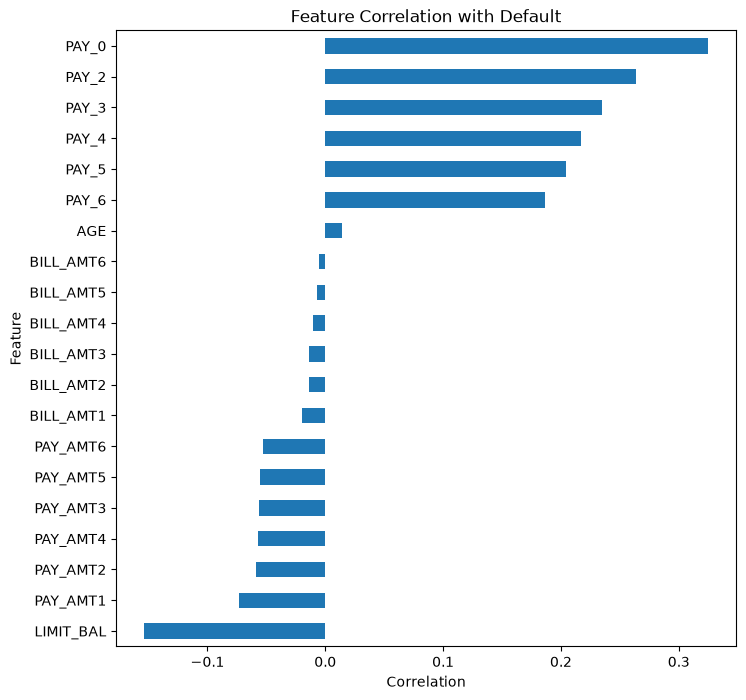

In [59]:
default_corr.plot(kind="barh", figsize=(8, 8))

plt.title("Feature Correlation with Default")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

Correlation analysis provides an initial view of linear relationships
between numerical variables and the target.

Repayment-status variables may show stronger relationships with default
than some demographic or financial amount variables.

Correlation alone does not determine predictive importance, especially
when relationships are non-linear.

### Outlier Inspection

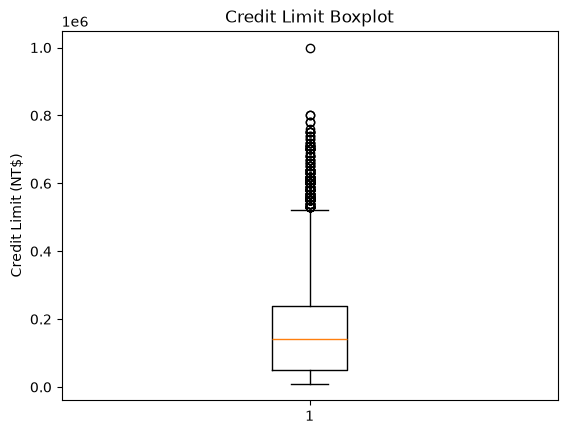

In [61]:
plt.boxplot(df["LIMIT_BAL"])

plt.title("Credit Limit Boxplot")
plt.ylabel("Credit Limit (NT$)")
plt.show()

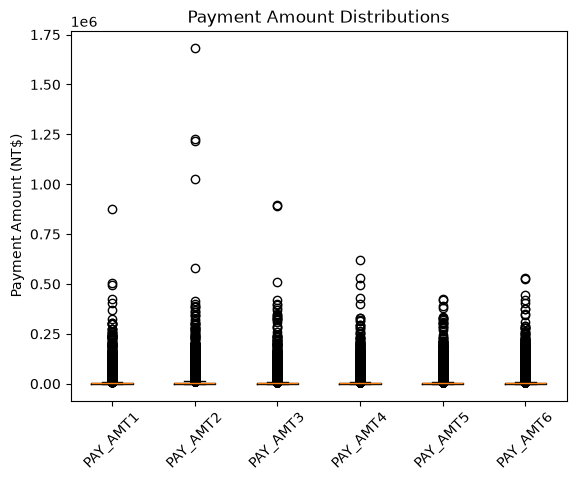

In [62]:
plt.boxplot(
    df[payment_cols],
    tick_labels=payment_cols
)

plt.title("Payment Amount Distributions")
plt.ylabel("Payment Amount (NT$)")
plt.xticks(rotation=45)
plt.show()

Financial variables contain extreme observations.

These observations are not removed automatically because high credit
limits, large bills, or large payments may represent legitimate
customer behavior.

Potential transformations or robust preprocessing techniques will be
considered later if required by the selected machine learning model.

## EDA Summary

### Key Findings

1. **Default Distribution**
   - Approximately XX% of customers defaulted in the following month.
   - The target therefore shows moderate class imbalance.

2. **Repayment Behavior**
   - Customers with recent payment delays showed a higher default rate.
   - Default risk generally increased as the number of delayed months increased.

3. **Credit Limit**
   - Customers in ______ credit-limit groups showed ______ default rates.

4. **Customer Demographics**
   - Differences in default rates across age, sex, education, and marital
     status were ______.

5. **Payment Behavior**
   - Default customers generally showed ______ historical payment amounts
     compared with non-default customers.

6. **Bill Amount**
   - Bill balances showed ______ differences between the two groups.

### Implications for Modeling

Repayment history appears to contain potentially strong predictive
information.

The EDA also suggests that behavioral features derived from historical
repayment data may be useful during feature engineering.